# Phase 1 — Data Exploration

**Goal:** Before doing any analysis, you must *understand* the data.
Analysts who skip this step make wrong conclusions.

By the end of this notebook you will know:
- The shape and structure of the dataset
- What each column means
- Where the nulls are
- How events are distributed

---

## What is GTM Analysis?

**Go-To-Market (GTM) Analysis** is the process of understanding how users move through your product or store.

For an e-commerce store, the GTM funnel is:

```
AWARENESS     → User views a product page
CONSIDERATION → User adds product to cart
CONVERSION    → User completes purchase
```

Your job as a GTM analyst: **find where users drop off and recommend fixes.**

Every number you produce must answer the question: *"What should the business do?"*

## Why explore data first?

Imagine you are a detective. You do not accuse someone before examining the scene.
Same rule: never run analysis on data you don't understand.

You are looking for:
1. **Shape** — how many rows, how many columns?
2. **Types** — are columns the right type (string, number, datetime)?
3. **Nulls** — are there missing values? In which columns?
4. **Distribution** — how are events spread across types?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# Load 500k rows — representative sample, fast to run
# In real work you'd load all data on a server with more RAM
df = pd.read_csv("../data/2019-Oct.csv", nrows=500_000)

print(f"Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")

Loaded: 500,000 rows x 9 columns


## Step 1 — Look at the raw data

Always do this first. You need a gut feel before writing any code.

In [2]:
df.head(10)

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-01 00:00:00 UTC,view,44600062,2103807459595387724,NaN,shiseido,35.79,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c
1,2019-10-01 00:00:00 UTC,view,3900821,2053013552326770905,appliances.environment.water_heater,aqua,33.20,554748717,9333dfbd-b87a-4708-9857-6336556b0fcc
2,2019-10-01 00:00:01 UTC,view,17200506,2053013559792632471,furniture.living_room.sofa,NaN,543.10,519107250,566511c2-e2e3-422b-b695-cf8e6e792ca8
3,2019-10-01 00:00:01 UTC,view,1307067,2053013558920217191,computers.notebook,lenovo,251.74,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713
4,2019-10-01 00:00:04 UTC,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.98,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d
5,2019-10-01 00:00:05 UTC,view,1480613,2053013561092866779,computers.desktop,pulser,908.62,512742880,0d0d91c2-c9c2-4e81-90a5-86594dec0db9
6,2019-10-01 00:00:08 UTC,view,17300353,2053013553853497655,NaN,creed,380.96,555447699,4fe811e9-91de-46da-90c3-bbd87ed3a65d
7,2019-10-01 00:00:08 UTC,view,31500053,2053013558031024687,NaN,luminarc,41.16,550978835,6280d577-25c8-4147-99a7-abc6048498d6
8,2019-10-01 00:00:10 UTC,view,28719074,2053013565480109009,apparel.shoes.keds,baden,102.71,520571932,ac1cd4e5-a3ce-4224-a2d7-ff660a105880
9,2019-10-01 00:00:11 UTC,view,1004545,2053013555631882655,electronics.smartphone,huawei,566.01,537918940,406c46ed-90a4-4787-a43b-59a410c1a5fb


## Step 2 — Column types and null counts

`df.info()` is your first diagnostic tool.

**What to look for:**
- `event_time` will be `object` — we convert it later
- `category_code` and `brand` often have nulls — not all products are tagged
- `user_id` should NEVER be null — if it is, those rows are useless for funnel analysis

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   event_time     500000 non-null  object 
 1   event_type     500000 non-null  object 
 2   product_id     500000 non-null  int64  
 3   category_id    500000 non-null  int64  
 4   category_code  341561 non-null  object 
 5   brand          428149 non-null  object 
 6   price          500000 non-null  float64
 7   user_id        500000 non-null  int64  
 8   user_session   500000 non-null  object 
dtypes: float64(1), int64(3), object(5)
memory usage: 34.3+ MB


## Step 3 — Null analysis

Nulls in the wrong column break your funnel math.

In [4]:
null_counts = df.isnull().sum()
null_pct    = (null_counts / len(df) * 100).round(2)

null_summary = pd.DataFrame({
    "null_count": null_counts,
    "null_pct":   null_pct
}).sort_values("null_pct", ascending=False)

print(null_summary)
print()
print("KEY QUESTION: Is user_id ever null? Check above.")
print("If yes, you must drop those rows before funnel analysis.")

               null_count  null_pct
category_code      158439     31.69
brand               71851     14.37
event_time              0      0.00
event_type              0      0.00
product_id              0      0.00
category_id             0      0.00
price                   0      0.00
user_id                 0      0.00
user_session            0      0.00

KEY QUESTION: Is user_id ever null? Check above.
If yes, you must drop those rows before funnel analysis.


## Step 4 — Event distribution

This is the most important first look.

The `event_type` column drives your entire funnel.

**Expected pattern:**
- `view` → largest (most common action)
- `cart` → much smaller
- `purchase` → smallest

If `purchase > cart` → data quality problem. Stop and investigate.

In [5]:
event_counts = df["event_type"].value_counts()
print("Event counts:")
print(event_counts)
print()
print("As percentages:")
print((event_counts / len(df) * 100).round(2).astype(str) + "%")

Event counts:
event_type
view        481833
purchase      9758
cart          8409
Name: count, dtype: int64

As percentages:
event_type
view        96.37%
purchase     1.95%
cart         1.68%
Name: count, dtype: object


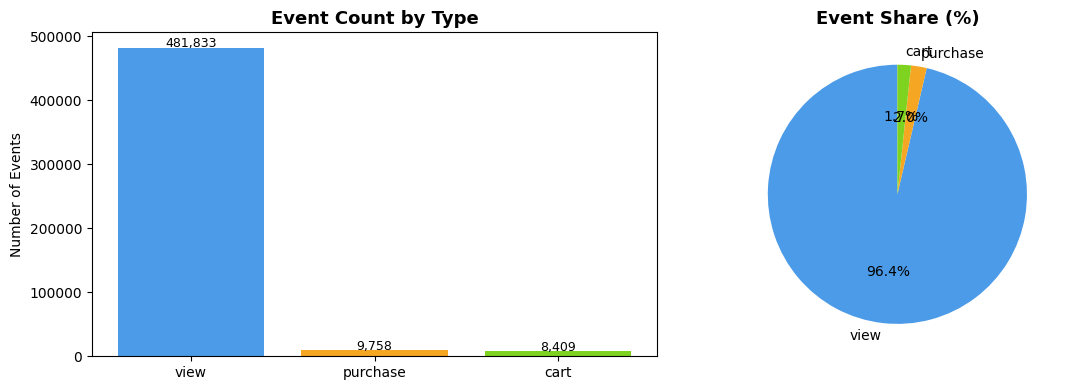

Saved to outputs/01_event_distribution.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = ["#4C9BE8", "#F5A623", "#7ED321"]

axes[0].bar(event_counts.index, event_counts.values, color=colors)
axes[0].set_title("Event Count by Type", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Number of Events")
for i, (k, v) in enumerate(event_counts.items()):
    axes[0].text(i, v + 500, f"{v:,}", ha="center", fontsize=9)

axes[1].pie(event_counts.values, labels=event_counts.index,
            autopct="%1.1f%%", colors=colors, startangle=90)
axes[1].set_title("Event Share (%)", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig("../outputs/01_event_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to outputs/01_event_distribution.png")

## Step 5 — Date range check

Understand the time window. This matters when you look at daily/weekly trends later.

In [7]:
df["event_time"] = pd.to_datetime(df["event_time"])

print(f"Earliest event : {df['event_time'].min()}")
print(f"Latest event   : {df['event_time'].max()}")
print(f"Span           : {(df['event_time'].max() - df['event_time'].min()).days} days")

Earliest event : 2019-10-01 00:00:00+00:00
Latest event   : 2019-10-01 10:22:43+00:00
Span           : 0 days


## Step 6 — Price distribution

Understanding price range sets context for interpreting cart abandonment later.

Purchase price stats:
count    9758.000000
mean      319.283086
std       356.901386
min         0.790000
25%        91.445000
50%       181.535000
75%       388.810000
max      2573.790000
Name: price, dtype: float64


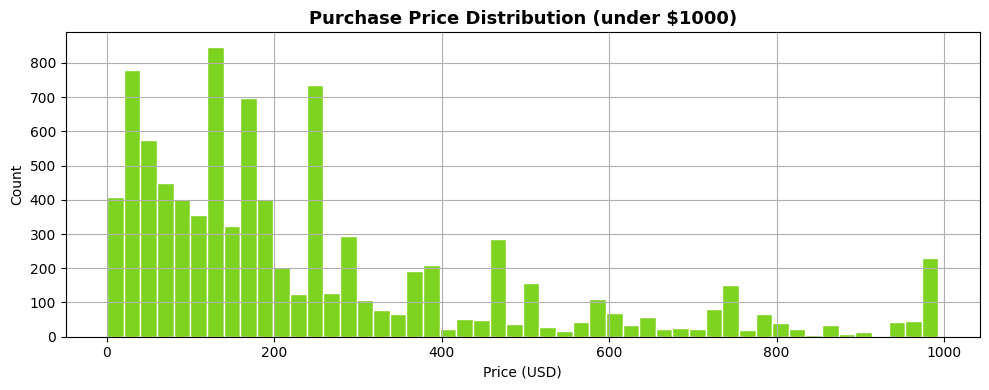

In [8]:
print("Purchase price stats:")
print(df[df["event_type"] == "purchase"]["price"].describe())

plt.figure(figsize=(10, 4))
purchase_prices = df[df["event_type"] == "purchase"]["price"].dropna()
purchase_prices[purchase_prices < 1000].hist(bins=50, color="#7ED321", edgecolor="white")
plt.title("Purchase Price Distribution (under $1000)", fontsize=13, fontweight="bold")
plt.xlabel("Price (USD)")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("../outputs/01_price_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## Checkpoint — Answer these before moving on

Before opening Notebook 02, answer these 5 questions from memory or from your outputs:

1. How many rows are in this dataset?
2. What % of events are `view`?
3. Which column has the most nulls — does that affect funnel analysis?
4. What is the median purchase price?
5. How many days does the dataset span?

**If you can't answer all 5 — go back and re-read your outputs.**

---
➡️ Next: `02_funnel_analysis.ipynb`

In [9]:
print(df["event_time"].min())
print(df["event_time"].max())
print(df["event_time"].dt.date.nunique(), "unique dates in your sample")

2019-10-01 00:00:00+00:00
2019-10-01 10:22:43+00:00
1 unique dates in your sample


In [10]:
df = pd.read_csv("../data/2019-Oct.csv")
df = df.sample(n=500_000, random_state=42).reset_index(drop=True)
df["event_time"] = pd.to_datetime(df["event_time"])
print(df["event_time"].dt.date.nunique(), "unique dates")

31 unique dates
